https://rhodesmill.org/skyfield/toc.html

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
# %matplotlib widget
%matplotlib inline


In [66]:
earth_radius = 6371 * 1e3

In [67]:
max_slant_angle = np.radians(60)
ang1 = np.linspace(0, 1, 360) * max_slant_angle
ang2 = np.linspace(0, 1, 360) * max_slant_angle
sat_alts = np.arange(200, 1000+1, 100) * 1e3
ang1_deg = np.degrees(ang1); ang2_deg = np.degrees(ang2)
ang1_mesh, ang2_mesh, sat_alt_mesh = np.meshgrid(ang1, ang2, sat_alts)
ang1_mesh_deg = np.degrees(ang1_mesh); ang2_mesh_deg = np.degrees(ang2_mesh)
sphere_x = (earth_radius + sat_alt_mesh) * np.cos(ang1_mesh) * np.cos(ang2_mesh)
sphere_y = (earth_radius + sat_alt_mesh) * np.cos(ang1_mesh) * np.sin(ang2_mesh)
sphere_z = (earth_radius + sat_alt_mesh) * np.sin(ang1_mesh)

sat_sphere = np.stack((sphere_x, sphere_y, sphere_z))
print(sat_sphere.shape)

(3, 360, 360, 9)


In [68]:
gs = np.array([earth_radius, 0, 0])
sat_vecs = sat_sphere - gs[:, np.newaxis, np.newaxis, np.newaxis]
sat_distance = np.linalg.norm(sat_vecs, axis=0)
sat_ground_projection = sat_distance * np.cos(ang1_mesh)
print(sat_vecs.shape, sat_distance.shape, sat_ground_projection.shape)

zenith_idx = np.argmin(np.abs(ang1))
print(f"Zenith index: {zenith_idx}, angle: {ang1[zenith_idx]:.2f} rad, {ang1_deg[zenith_idx]:.2f} deg")


(3, 360, 360, 9) (360, 360, 9) (360, 360, 9)
Zenith index: 0, angle: 0.00 rad, 0.00 deg


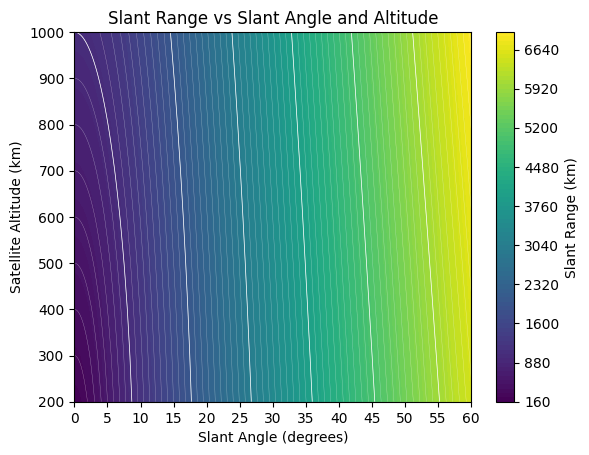

In [74]:
fig = plt.figure()
ax = plt.subplot(111)
# dist_map = ax.contourf(ang1_mesh_deg[:, :, 0], ang2_mesh_deg[:, :, 0], sat_distance[:, :, 0] / 1e3, levels=50, cmap='viridis')
# range_curve = ax.contour(ang1_mesh_deg[:, :, 0], ang2_mesh_deg[:, :, 0], sat_distance[:, :, 0] / 1e3, levels=[4000], colors='white', linewidths=0.5)
# fig.colorbar(dist_map, ax=ax, label='Distance to Satellite (km)')
# ax.set_xlabel('Azimuth (degrees)')
# ax.set_ylabel('Elevation (degrees)')

dist_map = ax.contourf(ang1_mesh_deg[zenith_idx, :, :], sat_alt_mesh[zenith_idx, :, :] / 1e3, sat_distance[zenith_idx, :, :] / 1e3, levels=100, cmap='viridis')
range_curve = ax.contour(ang1_mesh_deg[zenith_idx, :, :], sat_alt_mesh[zenith_idx, :, :] / 1e3, sat_distance[zenith_idx, :, :] / 1e3, levels=np.arange(1e3, 1e4, 1e3), colors='white', linewidths=0.5)
range_curve = ax.contour(ang1_mesh_deg[zenith_idx, :, :], sat_alt_mesh[zenith_idx, :, :] / 1e3, sat_distance[zenith_idx, :, :] / 1e3, levels=np.arange(.1e3, 1e4, .1e3), colors='white', linewidths=0.25, alpha=0.5)
fig.colorbar(dist_map, ax=ax, label='Slant Range (km)')
ax.set_xlabel('Slant Angle (degrees)')
ax.set_xticks(np.arange(0, 61, 5))
ax.set_ylabel('Satellite Altitude (km)')
# ax.set_aspect('equal')
ax.set_title('Slant Range vs Slant Angle and Altitude')
plt.show()

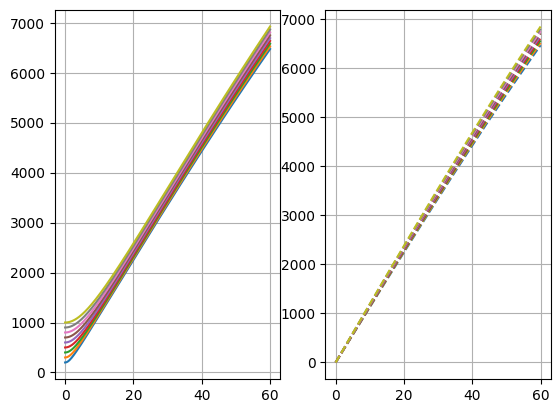

In [70]:
fig = plt.figure()
ax = plt.subplot(121)
ax_prj = plt.subplot(122)

for i, alt in enumerate(sat_alts):
  ax.plot(ang1_mesh_deg[zenith_idx, :, i], sat_distance[:, zenith_idx, i] / 1e3, label=f'{alt/1e3:.0f} km')
  ax_prj.plot(ang1_mesh_deg[zenith_idx, :, i], (np.sqrt(sat_distance[:, zenith_idx, i]**2 - alt**2)) / 1e3, label=f'{alt/1e3:.0f} km (ground proj)', linestyle='--')
  
ax.autoscale_view()
ax.grid()
ax_prj.autoscale_view()
ax_prj.grid()
plt.show()
